
Exploratory Data Analysis (EDA)
 US Visa Approval Dataset


In [2]:

 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 


#  STEP 1 — Load the data

 We saved this file in Phase 1 when we pulled data from MySQL
 and split it into train and test
 

In [3]:

df = pd.read_csv('../artifact/USvisaPipeline/data_ingestion/ingested/train.csv')
 


In [4]:
df.shape

(20384, 12)

In [5]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV15753,South America,High School,Y,N,2516,1995,West,34293.61,Year,Y,Denied
1,EZYV17312,Asia,Doctorate,N,N,2868,2013,Midwest,166380.37,Year,Y,Certified
2,EZYV9193,Asia,High School,Y,N,3273,1892,West,34431.42,Year,Y,Denied
3,EZYV23803,Asia,Master's,Y,N,1892,2000,West,21367.96,Year,Y,Denied
4,EZYV7868,Asia,Bachelor's,N,N,414,2004,Midwest,149629.63,Year,Y,Certified


#  STEP 2 — Understand each column

 dtypes tells me which columns are text (object)
 and which are numbers (int64, float64)

In [6]:
print(df.dtypes)
print()

case_id                      str
continent                    str
education_of_employee        str
has_job_experience           str
requires_job_training        str
no_of_employees            int64
yr_of_estab                int64
region_of_employment         str
prevailing_wage          float64
unit_of_wage                 str
full_time_position           str
case_status                  str
dtype: object



In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20384 entries, 0 to 20383
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                20384 non-null  str    
 1   continent              20384 non-null  str    
 2   education_of_employee  20384 non-null  str    
 3   has_job_experience     20384 non-null  str    
 4   requires_job_training  20384 non-null  str    
 5   no_of_employees        20384 non-null  int64  
 6   yr_of_estab            20384 non-null  int64  
 7   region_of_employment   20384 non-null  str    
 8   prevailing_wage        20384 non-null  float64
 9   unit_of_wage           20384 non-null  str    
 10  full_time_position     20384 non-null  str    
 11  case_status            20384 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.7 MB



#  STEP 3 — Basic statistics

 describe() gives mean, min, max, std for number columns
 For text columns it gives count, unique, top value, frequency
 


In [8]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,20384.00000,20384.000000,20384.000000
mean,5687.86509,1979.536107,74495.204542
std,23015.10342,42.217372,52883.285956
min,-26.00000,1800.000000,2.136700
25%,1021.00000,1976.000000,34114.920000
50%,2104.00000,1997.000000,70378.525000
75%,3508.00000,2005.000000,107692.895000
max,602069.00000,2016.000000,315497.600000


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0



#  STEP 4 — Check for missing values


 



In [9]:
missing = df.isnull().sum()
print(missing)

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


Series([], dtype: float64)


 

#  STEP 5 — Look at the target column

Our target is 'case_status' — Certified or Denied
 This is what our model will try to predict



  INTERVIEW ANSWER:
 "The target column has two classes — Certified and Denied.
  I checked their distribution to see if there is class imbalance."

In [10]:

 
# First just count how many of each we have
print(df['case_status'].value_counts())
print()
print(df['case_status'].value_counts(normalize=True) * 100)
 

case_status
Certified    13614
Denied        6770
Name: count, dtype: int64

case_status
Certified    66.787677
Denied       33.212323
Name: proportion, dtype: float64



#  STEP 6 — Class imbalance check

 Class imbalance = one class has far more samples than the other

 PROBLEM: if 90% of data is Certified and 10% is Denied,
 the model will just predict Certified for everything
 and still get 90% accuracy — but it is useless!

SOLUTION: SMOTE — creates synthetic new samples of minority class

Certified: 13614
Denied   : 6770
Ratio    : 2.01:1
Class imbalance exists — will apply SMOTE in Phase 5


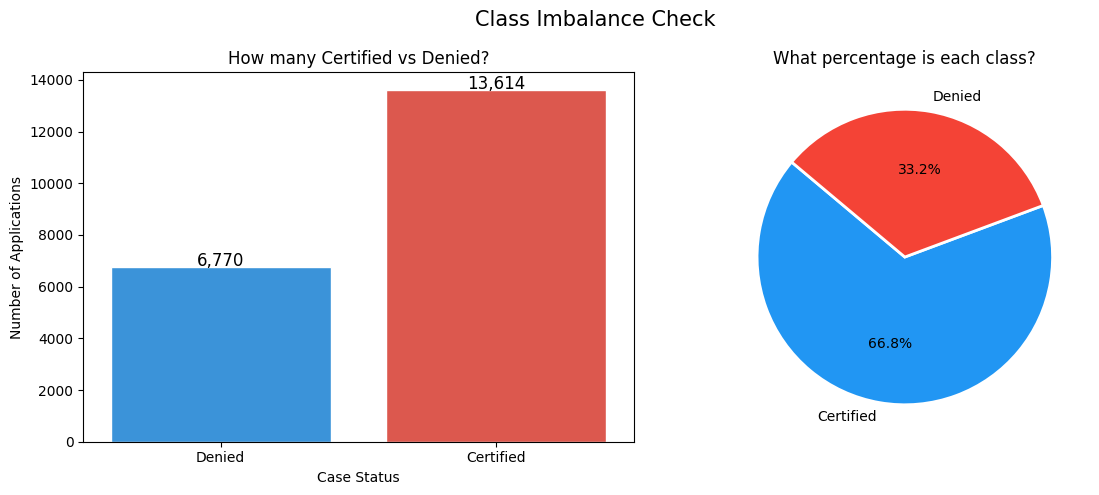

In [11]:

 
certified_count = (df['case_status'] == 'Certified').sum()
denied_count    = (df['case_status'] == 'Denied').sum()
ratio           = certified_count / denied_count
 
print(f"Certified: {certified_count}")
print(f"Denied   : {denied_count}")
print(f"Ratio    : {ratio:.2f}:1")
 
if ratio > 1.5:
    print("Class imbalance exists — will apply SMOTE in Phase 5")
else:
    print("Classes are balanced — no special treatment needed")
 
 # I want to see the class distribution in two ways:
# 1. Bar chart  → shows exact counts
# 2. Pie chart  → shows percentages
# So I create two plots side by side

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


# --- Bar Chart ---
# countplot automatically counts Certified vs Denied for me
# I just tell it which column to use

sns.countplot(
    data     = df,
    x        = 'case_status',
    palette  = ['#2196F3', '#F44336'],  # blue = certified, red = denied
    ax       = ax1,
    edgecolor= 'white'
)

ax1.set_title('How many Certified vs Denied?')
ax1.set_xlabel('Case Status')
ax1.set_ylabel('Number of Applications')

# I want to show the exact number on top of each bar
# ax1.patches gives me each bar as an object
# I loop through them and write the count above each one

for bar in ax1.patches:
    ax1.text(
        x        = bar.get_x() + bar.get_width() / 2,  # center of bar
        y        = bar.get_height() + 30,               # just above the bar
        s        = f'{int(bar.get_height()):,}',        # the count with comma
        ha       = 'center',
        fontsize = 12
    )


# --- Pie Chart ---
# First I get the counts for each class
# then I pass them directly to pie()

counts = df['case_status'].value_counts()

ax2.pie(
    counts,
    labels     = counts.index,       # Certified, Denied as labels
    autopct    = '%1.1f%%',          # show percentage like 67.3%
    colors     = ['#2196F3', '#F44336'],
    startangle = 140,                # rotate so it looks balanced
    wedgeprops = {
        'edgecolor' : 'white',
        'linewidth' : 2              # white border between slices
    }
)

ax2.set_title('What percentage is each class?')


# --- Final touches ---
plt.suptitle('Class Imbalance Check', fontsize=15)
plt.tight_layout()
plt.savefig('02_class_imbalance.png', dpi=150)
plt.show()


# INTERVIEW ANSWER:
 "I found X% Certified and Y% Denied — this is class imbalance.
  I used SMOTE (Synthetic Minority Oversampling Technique) to fix it.
  SMOTE creates new synthetic samples of the minority class
  by interpolating between existing samples — not just copying them."


#  STEP 7 — Categorical features

 Categorical columns = text columns like continent, education
 I want to know:
 1. How many unique values does each have?
 2. Which values are most common?
 3. Do certain values lead to more visa approvals?
 
 Get all text columns except the target and the case_id which is always unique

In [12]:
columns_to_exclude = ['case_id', 'case_status']

cat_cols = [col for col in df.select_dtypes('object').columns
            if col not in columns_to_exclude]

print(f"Categorical columns: {cat_cols}")

Categorical columns: ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position']


In [12]:
# Check unique values in each
for col in cat_cols:
    print(f"{col} has {df[col].nunique()} unique values:")
    print(df[col].value_counts())
    

continent has 6 unique values:
continent
Asia             13500
Europe            2973
North America     2635
South America      686
Africa             444
Oceania            146
Name: count, dtype: int64
education_of_employee has 4 unique values:
education_of_employee
Bachelor's     8189
Master's       7705
High School    2754
Doctorate      1736
Name: count, dtype: int64
has_job_experience has 2 unique values:
has_job_experience
Y    11837
N     8547
Name: count, dtype: int64
requires_job_training has 2 unique values:
requires_job_training
N    17987
Y     2397
Name: count, dtype: int64
region_of_employment has 5 unique values:
region_of_employment
Northeast    5765
South        5616
West         5259
Midwest      3456
Island        288
Name: count, dtype: int64
unit_of_wage has 4 unique values:
unit_of_wage
Year     18367
Hour      1726
Week       219
Month       72
Name: count, dtype: int64
full_time_position has 2 unique values:
full_time_position
Y    18232
N     2152
Name: count

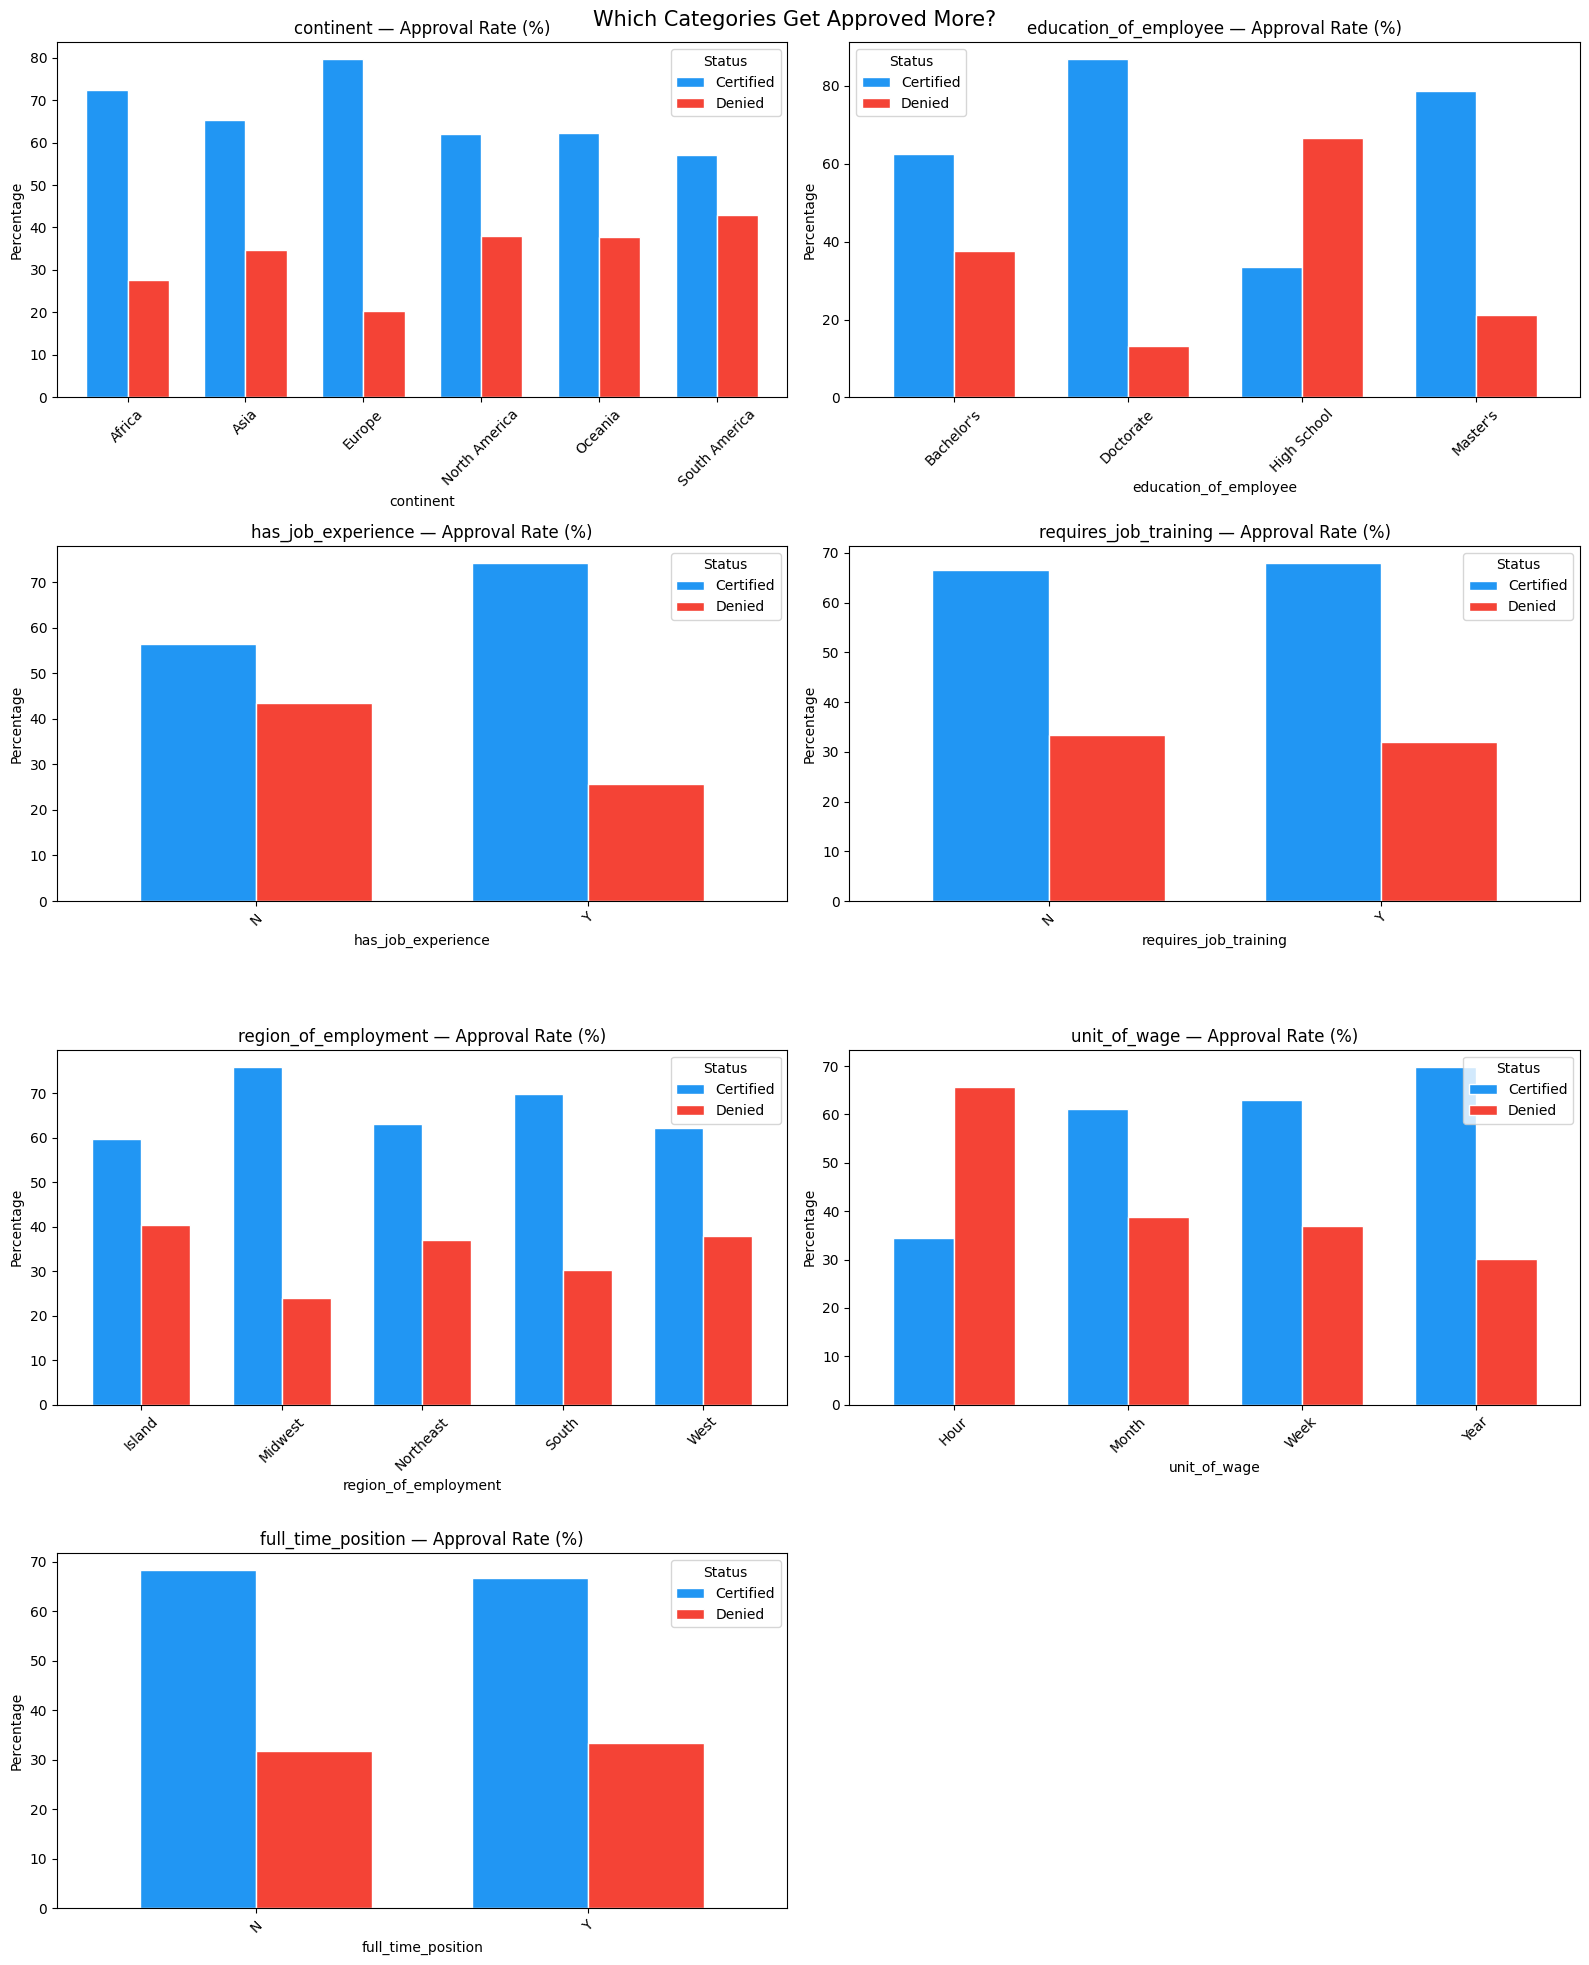

In [16]:
# Now I want to visually see which categories
# get visa approved more vs denied
# I use crosstab with normalize='index'
# so each bar shows PERCENTAGE not count

columns_to_exclude = ['case_id', 'case_status']

cat_cols = [
    col for col in df.select_dtypes('object').columns
    if col not in columns_to_exclude
]

n_rows = (len(cat_cols) + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    # normalize='index' → shows % within each category
    # example: "of all applicants from Asia, 67% got certified"
    ct = pd.crosstab(
        df[col],
        df['case_status'],
        normalize = 'index'
    ) * 100

    ct.plot(
        kind      = 'bar',
        ax        = axes[i],
        color     = ['#2196F3', '#F44336'],
        edgecolor = 'white',
        width     = 0.7
    )

    axes[i].set_title(f'{col} — Approval Rate (%)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Status')

# hide empty subplots if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Which Categories Get Approved More?', fontsize=15)
plt.tight_layout()
plt.savefig('03_categorical_vs_target.png', dpi=150)
plt.show()



# Numerical features

 Numerical columns = number columns like no_of_employees, wages
 I want to know:
 1. What does the distribution look like? (normal? skewed?)
 2. Are there extreme outliers?
 3. Is the spread different for Certified vs Denied?

Numerical columns: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

no_of_employees:
  mean   = 5687.87
  median = 2104.00
  std    = 23015.10
  min    = -26.00
  max    = 602069.00

yr_of_estab:
  mean   = 1979.54
  median = 1997.00
  std    = 42.22
  min    = 1800.00
  max    = 2016.00

prevailing_wage:
  mean   = 74495.20
  median = 70378.52
  std    = 52883.29
  min    = 2.14
  max    = 315497.60


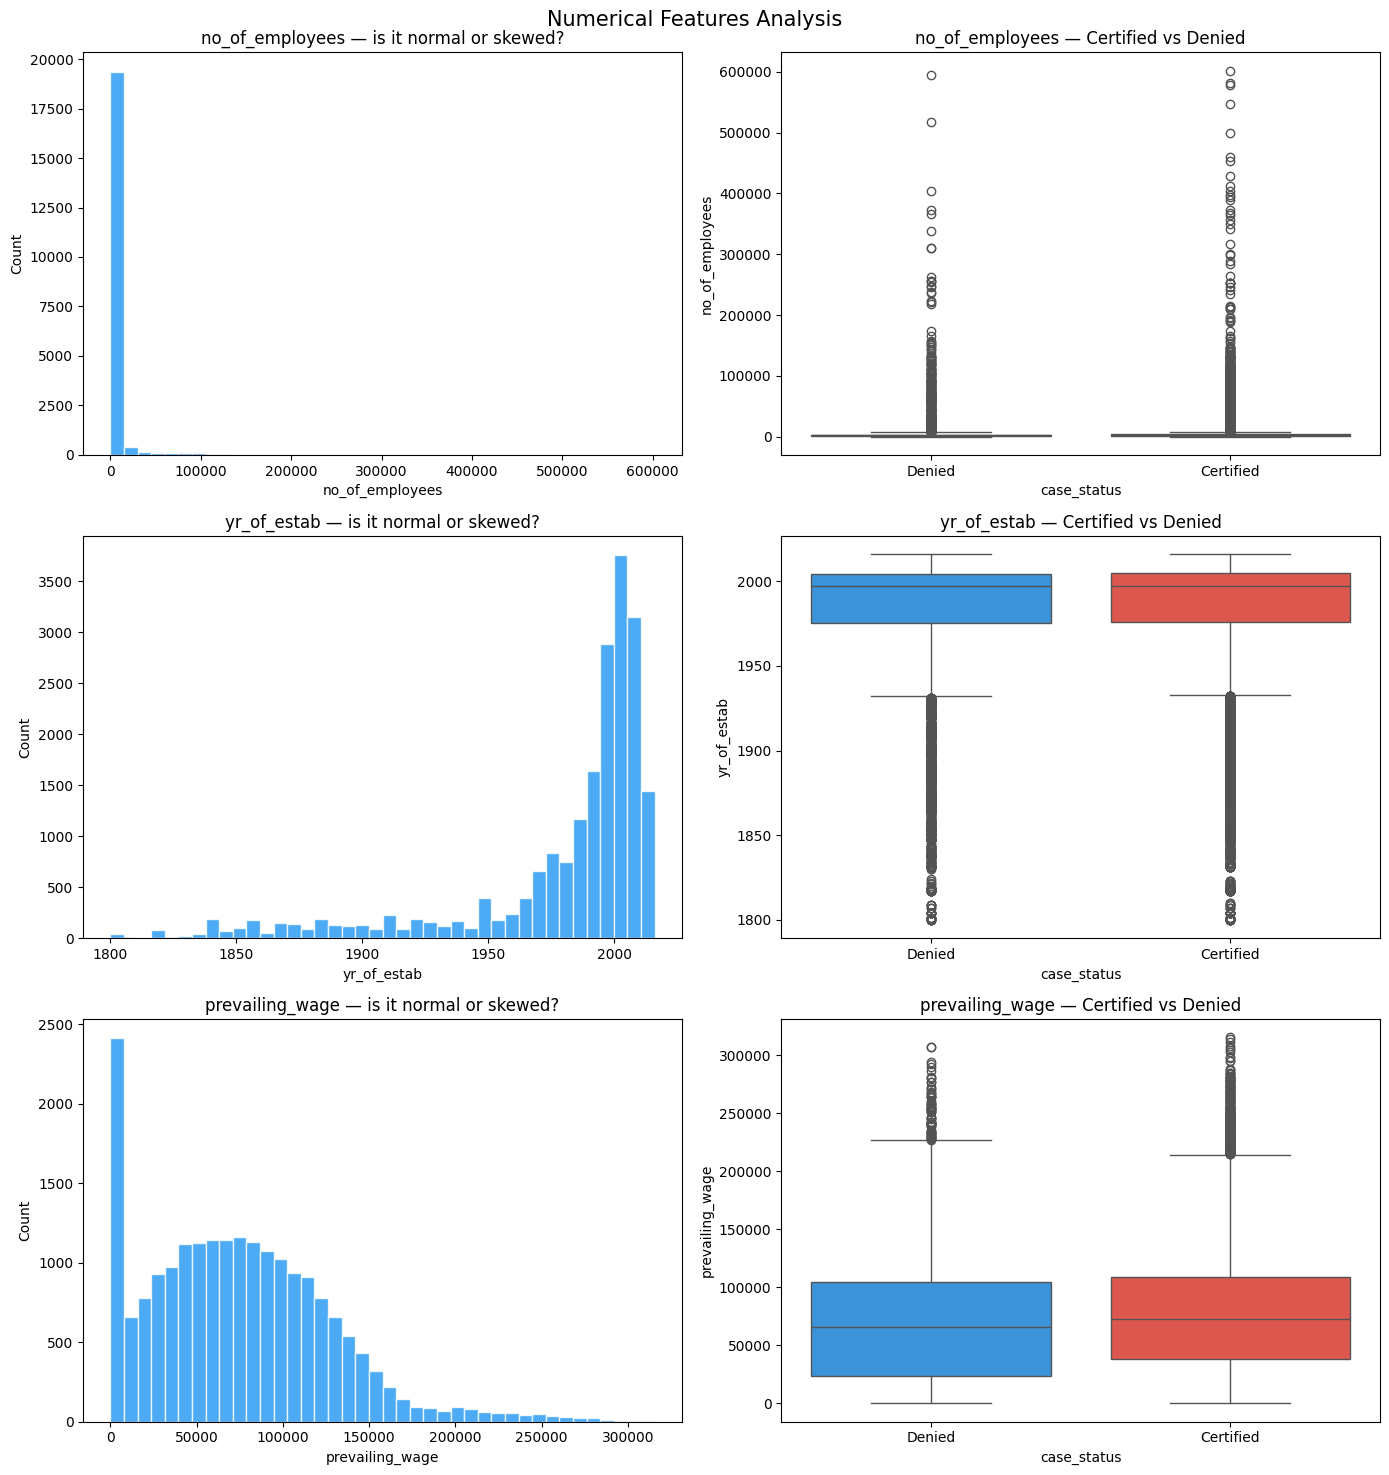

In [ ]:

 
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
 
print(f"Numerical columns: {num_cols}")
 
if len(num_cols) == 0:
    print("No numerical columns found")
else:
    for col in num_cols:
        print(f"\n{col}:")
        print(f"  mean   = {df[col].mean():.2f}")
        print(f"  median = {df[col].median():.2f}")
        print(f"  std    = {df[col].std():.2f}")
        print(f"  min    = {df[col].min():.2f}")
        print(f"  max    = {df[col].max():.2f}")
 
    
 
# INTERVIEW ANSWER:
# "If histogram shows right skew (long tail on right side),
#  I apply log transformation to make it more normal.
#  Normal distribution helps many ML algorithms perform better.
#  Boxplot whiskers show me where outliers start."
 

In [19]:
# =============================================================
#  STEP 9 — Outlier detection using IQR
# =============================================================
# IQR = Q3 - Q1 (middle 50% of data)
# Outlier rule:
#   anything below  Q1 - 1.5 * IQR  is a low outlier
#   anything above  Q3 + 1.5 * IQR  is a high outlier
 
print("\nOutlier Detection:")
print("-" * 40)
 
if len(num_cols) > 0:
    for col in num_cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
 
        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR
 
        outliers = df[(df[col] < lower_fence) | (df[col] > upper_fence)]
        pct      = round(len(outliers) / len(df) * 100, 2)
 
        print(f"{col}: {len(outliers)} outliers ({pct}%)")
        print(f"  Safe range: {lower_fence:.1f} to {upper_fence:.1f}")
 
# INTERVIEW ANSWER:
# "I used the IQR method because it is based on percentiles,
#  not the mean. So extreme values don't skew the boundaries.
#  Z-score method uses mean and std — those get affected by outliers.
#  IQR is more robust for skewed data."
 
 


Outlier Detection:
----------------------------------------
no_of_employees: 1277 outliers (6.26%)
  Safe range: -2709.5 to 7238.5
yr_of_estab: 2575 outliers (12.63%)
  Safe range: 1932.5 to 2048.5
prevailing_wage: 349 outliers (1.71%)
  Safe range: -76252.0 to 218059.9


In [16]:
def iqr_cap(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return s.clip(lo, hi)

df['no_of_employees_cap'] = iqr_cap(df['no_of_employees'])
df['prevailing_wage_cap'] = iqr_cap(df['prevailing_wage'])

df['no_of_employees_log'] = np.log1p(df['no_of_employees_cap'])
df['prevailing_wage_log'] = np.log1p(df['prevailing_wage_cap'])

has_job_experience encoded: <ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str → [1 0]
requires_job_training encoded: <ArrowStringArray>
['N', 'Y']
Length: 2, dtype: str → [0 1]
full_time_position encoded: <ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str → [1 0]

Shape after encoding : (20384, 22)
Columns after encoding:
['has_job_experience', 'requires_job_training', 'no_of_employees', 'yr_of_estab', 'prevailing_wage', 'full_time_position', 'case_status', 'continent_Asia', 'continent_Europe', 'continent_North America', 'continent_Oceania', 'continent_South America', 'education_of_employee_Doctorate', 'education_of_employee_High School', "education_of_employee_Master's", 'region_of_employment_Midwest', 'region_of_employment_Northeast', 'region_of_employment_South', 'region_of_employment_West', 'unit_of_wage_Month', 'unit_of_wage_Week', 'unit_of_wage_Year']

Feature correlation with case_status:
---------------------------------------------
case_status                          1.000

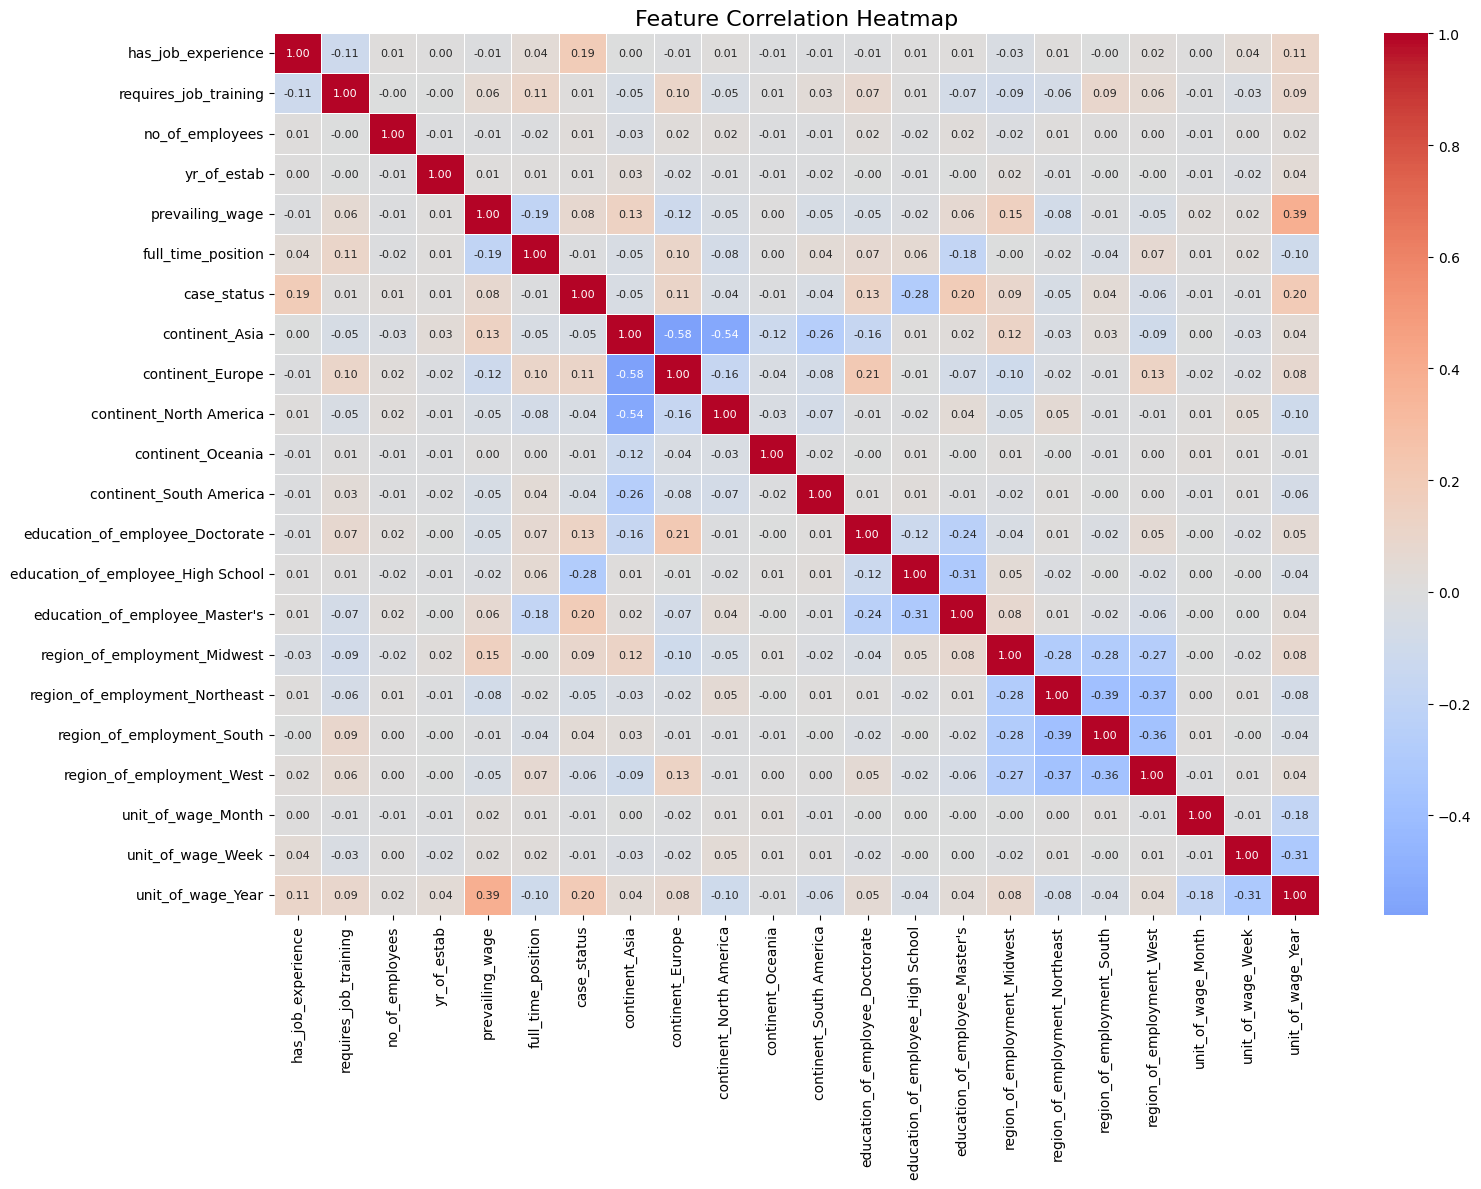

In [25]:
# Correlation Analysis
# I need to convert everything to numbers
# to calculate correlation
#
# I will use PROPER encoding here:
# Binary columns (Y/N)     → Label Encoding  (0 and 1)
# Multi value columns      → One Hot Encoding (separate columns)
# Target column            → map (Certified=1, Denied=0)

from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Step 1 — Drop case_id
# It is just an identifier — no relationship with visa approval
df_encoded = df_encoded.drop(columns=['case_id'])

# Step 2 — Encode target column
# Certified = 1, Denied = 0
df_encoded['case_status'] = df_encoded['case_status'].map(
    {'Certified': 1, 'Denied': 0}
)

# Step 3 — Label Encoding for binary columns (only 2 values)
# These columns only have Y or N
# So 0 and 1 makes perfect sense here

binary_cols = ['has_job_experience',
               'requires_job_training',
               'full_time_position']

le = LabelEncoder()

for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"{col} encoded: {df[col].unique()} → {df_encoded[col].unique()}")

# Step 4 — One Hot Encoding for multi value columns
# These columns have more than 2 unique values
# We cannot assign numbers like 0,1,2,3 because
# model will think higher number = more important
# which is WRONG for categories like continent

multi_cols = ['continent',
              'education_of_employee',
              'region_of_employment',
              'unit_of_wage']

df_encoded = pd.get_dummies(
    df_encoded,
    columns = multi_cols,
    drop_first = True   # drop first column to avoid multicollinearity
                        # example: if Asia=0 Europe=0 Africa=0
                        # we already know it is North America
                        # no need for extra column
)

print(f"\nShape after encoding : {df_encoded.shape}")
print(f"Columns after encoding:\n{df_encoded.columns.tolist()}")

# Step 5 — Calculate correlation
corr = df_encoded.corr()

# Show which features are most related to target
print("\nFeature correlation with case_status:")
print("-" * 45)
print(corr['case_status'].sort_values(ascending=False).to_string())

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'coolwarm',
    center     = 0,
    linewidths = 0.5,
    annot_kws  = {'size': 8}
)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', dpi=150)
plt.show()
# ```

# ---

# ## Why this is better than `cat.codes`:
# ```
# cat.codes ❌ (what we had before)
# ──────────────────────────────────────
# continent:
#   Africa        → 0
#   Asia          → 1
#   Europe        → 2
#   North America → 3
#   Oceania       → 4
#   South America → 5

# Model thinks:
# South America (5) > North America (3) > Asia (1)
# This is WRONG — continents have no order!


# One Hot Encoding ✅ (what we use now)
# ──────────────────────────────────────
# continent_Asia  continent_Europe  continent_Africa ...
#      1                0                  0
#      0                1                  0
#      0                0                  1

# Each continent is independent
# No false ordering
# Model treats them equally ✅
# ```

# ---

# ## What `drop_first=True` does:
# ```
# continent has 6 values:
# Asia, Africa, Europe, North America, Oceania, South America

# Without drop_first — 6 new columns created:
# continent_Asia
# continent_Africa
# continent_Europe
# continent_NorthAmerica
# continent_Oceania
# continent_SouthAmerica

# Problem:
# If all 5 are 0 → we ALREADY know it is SouthAmerica
# The 6th column gives NO new information
# This causes multicollinearity ❌

# With drop_first=True — only 5 new columns:
# continent_Africa
# continent_Europe
# continent_NorthAmerica
# continent_Oceania
# continent_SouthAmerica

# If all 5 are 0 → it is Asia (the dropped one)
# We still have all information ✅

In [21]:

# =============================================================
#  STEP 11 — What is the actual approval rate per category?
# =============================================================
# This is pure business insight.
# Before even training a model, this tells us
# which category values matter most.
 
print("\nVisa approval rate by category:")
print("=" * 50)
 
for col in cat_cols:
    print(f"\n{col}:")
    approval = (
        df.groupby(col)['case_status']
        .apply(lambda x: round((x == 'Certified').sum() / len(x) * 100, 1))
        .sort_values(ascending=False)
    )
    print(approval.to_string())
 
# INTERVIEW ANSWER:
# "This analysis directly tells me which feature values
#  increase or decrease visa approval chances.
#  It also validates business logic — for example,
#  having job experience should logically increase approval,
#  and the data should confirm that."


Visa approval rate by category:

continent:
continent
Europe           79.6
Africa           72.3
Asia             65.3
Oceania          62.3
North America    62.0
South America    57.1

education_of_employee:
education_of_employee
Doctorate      86.9
Master's       78.7
Bachelor's     62.5
High School    33.5

has_job_experience:
has_job_experience
Y    74.2
N    56.5

requires_job_training:
requires_job_training
Y    68.0
N    66.6

region_of_employment:
region_of_employment
Midwest      76.0
South        69.7
Northeast    63.0
West         62.1
Island       59.7

unit_of_wage:
unit_of_wage
Year     69.9
Week     63.0
Month    61.1
Hour     34.4

full_time_position:
full_time_position
N    68.3
Y    66.6
